<a href="https://colab.research.google.com/github/Nicoherr/PlantVillageTomato/blob/main/Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# 1. Conectar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta raíz para tu proyecto
proyecto_path = '/content/drive/MyDrive/proyecto_evaluacion_1_mlp'

# 3. Lista de subcarpetas requeridas
carpetas = [
    'data',
    'notebooks',
    'models',
    'images'
]

# 4. Crear las carpetas de forma automática
for carpeta in carpetas:
    ruta_completa = os.path.join(proyecto_path, carpeta)
    os.makedirs(ruta_completa, exist_ok=True)
    print(f"Carpeta creada o verificada: {ruta_completa}")

print("\n¡Estructura de carpetas lista en tu Google Drive!")

Mounted at /content/drive
Carpeta creada o verificada: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/data
Carpeta creada o verificada: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/notebooks
Carpeta creada o verificada: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/models
Carpeta creada o verificada: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/images

¡Estructura de carpetas lista en tu Google Drive!


In [2]:
import os
import shutil
import random
from glob import glob

# 1. Definir rutas
proyecto_path = '/content/drive/MyDrive/proyecto_evaluacion_1_mlp'
data_dir = os.path.join(proyecto_path, 'data')
raw_dir = '/content/plantdisease_raw'

# Fijar semilla para reproducibilidad
SEED = 2026
random.seed(SEED)

print("1. Descargando repositorio con las imágenes de PlantVillage...")
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git {raw_dir}

# 2. Definir las 4 clases de nuestra variante (Ejemplo: Tomate)
# Puedes cambiar las carpetas si prefieres otro cultivo
clases_seleccionadas = [
    'Tomato___healthy',
    'Tomato___Late_blight',
    'Tomato___Bacterial_spot',
    'Tomato___Leaf_Mold'
]

print("\n2. Filtrando subconjunto de imágenes para la variante...")
# Ruta interna del repositorio donde están las imágenes formateadas
source_folder = os.path.join(raw_dir, 'raw', 'color')

for cls in clases_seleccionadas:
    src_cls_path = os.path.join(source_folder, cls)
    dest_cls_path = os.path.join(data_dir, cls)
    os.makedirs(dest_cls_path, exist_ok=True)

    # Obtener todas las imágenes de esta clase
    imagenes = glob(os.path.join(src_cls_path, '*.JPG')) + glob(os.path.join(src_cls_path, '*.jpg'))

    # Tomar una muestra aleatoria de 500 imágenes por clase
    muestra = random.sample(imagenes, min(500, len(imagenes)))

    # Copiar a nuestra carpeta de Drive
    for img_path in muestra:
        shutil.copy(img_path, dest_cls_path)

    print(f" -> Clase '{cls}': {len(muestra)} imágenes guardadas en {dest_cls_path}")

print("\n¡Descarga y filtrado de la variante completados con éxito!")

1. Descargando repositorio con las imágenes de PlantVillage...
Cloning into '/content/plantdisease_raw'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 29.24 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.

2. Filtrando subconjunto de imágenes para la variante...
 -> Clase 'Tomato___healthy': 500 imágenes guardadas en /content/drive/MyDrive/proyecto_evaluacion_1_mlp/data/Tomato___healthy
 -> Clase 'Tomato___Late_blight': 500 imágenes guardadas en /content/drive/MyDrive/proyecto_evaluacion_1_mlp/data/Tomato___Late_blight
 -> Clase 'Tomato___Bacterial_spot': 500 imágenes guardadas en /content/drive/MyDrive/proyecto_evaluacion_1_mlp/data/Tomato___Bacterial_spot
 -> Clase 'Tomato___Leaf_Mold': 500 imágenes guardadas en

=== DISTRIBUCIÓN DEL DATASET (VARIANTE) ===
                     Clase  Cantidad de Imágenes
0         Tomato___healthy                   500
1     Tomato___Late_blight                   500
2  Tomato___Bacterial_spot                   500
3       Tomato___Leaf_Mold                   500

Total de imágenes: 2000

Resolución original de imagen de muestra: (256, 256, 3) (Alto x Ancho x Canales RGB)


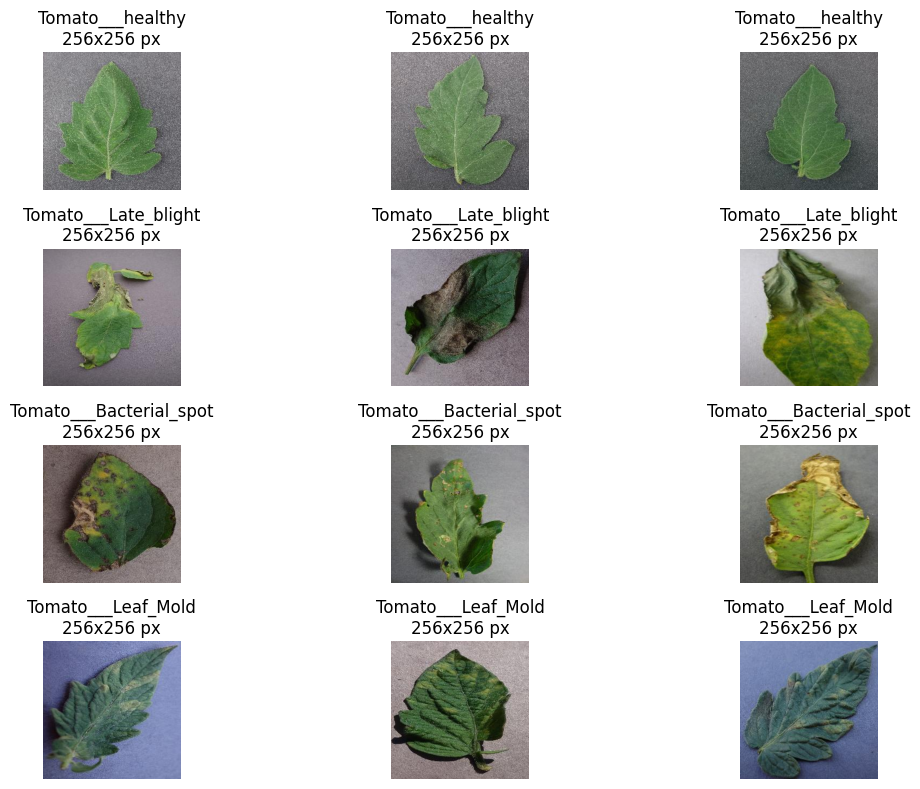


 Gráfica guardada exitosamente en: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/images/eda_muestras_clases.png


In [3]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

# Definir la ruta de datos en Google Drive
proyecto_path = '/content/drive/MyDrive/proyecto_evaluacion_1_mlp'
data_dir = os.path.join(proyecto_path, 'data')

# 1. Conteo de imágenes por clase
clases = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
conteo = {}
ejemplos_rutas = {}

for cls in clases:
    ruta_cls = os.path.join(data_dir, cls)
    imgs = glob(os.path.join(ruta_cls, '*.[jJ][pP][gG]'))
    conteo[cls] = len(imgs)
    if imgs:
        ejemplos_rutas[cls] = imgs[:3]  # Guardar 3 imágenes de muestra por clase

# Crear DataFrame resumen
df_resumen = pd.DataFrame(list(conteo.items()), columns=['Clase', 'Cantidad de Imágenes'])
print("=== DISTRIBUCIÓN DEL DATASET (VARIANTE) ===")
print(df_resumen)
print("\nTotal de imágenes:", df_resumen['Cantidad de Imágenes'].sum())

# 2. Verificar dimensiones de una imagen de muestra
muestra_img_path = ejemplos_rutas[clases[0]][0]
img_sample = cv2.imread(muestra_img_path)
img_sample_rgb = cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB)

print(f"\nResolución original de imagen de muestra: {img_sample.shape} (Alto x Ancho x Canales RGB)")

# 3. Visualizar imágenes por clase
plt.figure(figsize=(12, 8))
cols = 3
rows = len(clases)

for idx_cls, cls in enumerate(clases):
    for i in range(cols):
        img_p = ejemplos_rutas[cls][i]
        img = cv2.imread(img_p)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, idx_cls * cols + i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{cls}\n{img.shape[1]}x{img.shape[0]} px")
        plt.axis('off')

plt.tight_layout()
# Guardar la gráfica en la carpeta images/ para el informe final
grafico_path = os.path.join(proyecto_path, 'images', 'eda_muestras_clases.png')
plt.savefig(grafico_path, bbox_inches='tight')
plt.show()

print(f"\n Gráfica guardada exitosamente en: {grafico_path}")

In [4]:
import os
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Definir la ruta del proyecto
proyecto_path = '/content/drive/MyDrive/proyecto_evaluacion_1_mlp'
data_dir = os.path.join(proyecto_path, 'data')

# Parámetros del Preprocesamiento
IMG_SIZE = (64, 64)
SEED = 2026

X_list = []
y_list = []

# Obtener carpetas de clases
clases = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

print("Cargando y procesando imágenes...")
for cls in clases:
    ruta_cls = os.path.join(data_dir, cls)
    imgs_paths = glob(os.path.join(ruta_cls, '*.[jJ][pP][gG]'))

    for img_path in imgs_paths:
        # 1. Cargar imagen en BGR y pasar a RGB
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Redimensionar
        img_resized = cv2.resize(img, IMG_SIZE)

        # 3. Normalizar (0 a 1)
        img_normalized = img_resized.astype('float32') / 255.0

        # 4. Aplanar a vector 1D (64 * 64 * 3 = 12288)
        img_flattened = img_normalized.flatten()

        X_list.append(img_flattened)
        y_list.append(cls)

X = np.array(X_list)
y = np.array(y_list)

# Codificar etiquetas de texto a números (0, 1, 2, 3)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Dataset completo procesado: {X.shape[0]} muestras con {X.shape[1]} características cada una.")

# Divición de datos (70% Train, 15% Val, 15% Test) con semilla fija
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("\n=== PARTICIÓN DE DATOS COMPLETADA ===")
print(f"Entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Validación (Val):       {X_val.shape[0]} muestras")
print(f"Prueba (Test):         {X_test.shape[0]} muestras")
print("Clases codificadas:", dict(zip(le.classes_, range(len(le.classes_)))))

Cargando y procesando imágenes...
Dataset completo procesado: 2000 muestras con 12288 características cada una.

=== PARTICIÓN DE DATOS COMPLETADA ===
Entrenamiento (Train): 1400 muestras
Validación (Val):       300 muestras
Prueba (Test):         300 muestras
Clases codificadas: {np.str_('Tomato___Bacterial_spot'): 0, np.str_('Tomato___Late_blight'): 1, np.str_('Tomato___Leaf_Mold'): 2, np.str_('Tomato___healthy'): 3}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,508 (6.03 MB)

 Trainable params: 1,581,508 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3300 - loss: 1.7059 - val_accuracy: 0.4100 - val_loss: 1.2499
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4193 - loss: 1.2560 - val_accuracy: 0.5700 - val_loss: 1.1626
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4979 - loss: 1.1480 - val_accuracy: 0.6233 - val_loss: 1.0402
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5421 - loss: 1.0802 - val_accuracy: 0.6133 - val_loss: 0.9616
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5650 - loss: 1.0212 - val_accuracy: 0.6567 - val_loss: 0.9182
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5807 - loss: 0.9982 - val_accuracy: 0.6500 - val_loss: 0.8568
Epoch 7/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5779 - loss: 0.9829 - val_accuracy: 0.6933 - val_loss: 0.7850
Epoch 8/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6050 - loss: 0.9130 - val_accuracy: 0.6867 - v

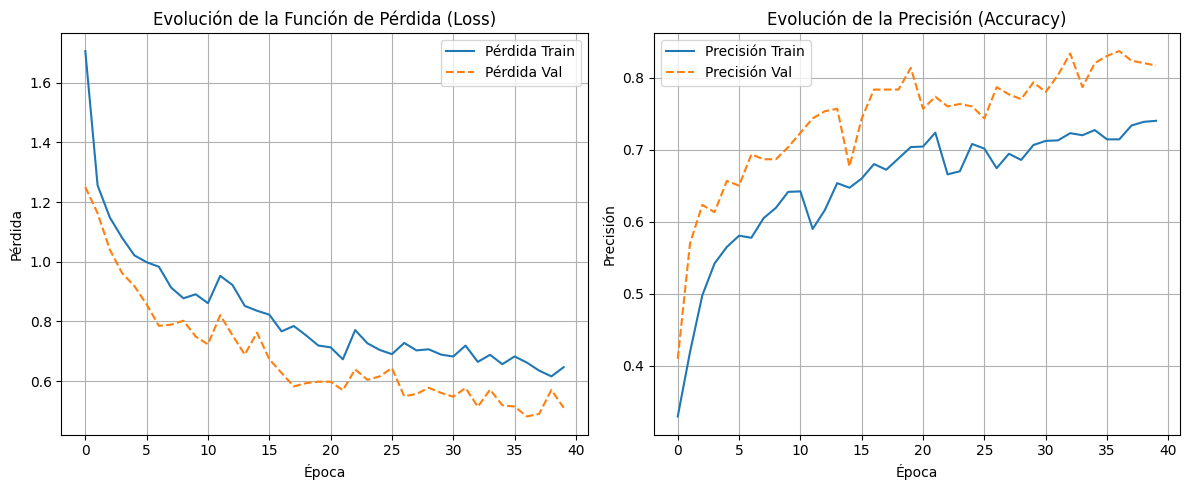


 Curvas de entrenamiento guardadas en: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/images/curvas_entrenamiento.png
 Modelo guardado con éxito en: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/models/modelo_mlp_plantdisease.h5


In [5]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Fijar semillas para reproducibilidad total
SEED = 2026
tf.random.set_seed(SEED)
np.random.seed(SEED)

# 1. Definir la arquitectura de la red MLP
model = Sequential([
    # Capa oculta 1
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    # Capa oculta 2
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Capa de salida (4 clases)
    Dense(len(le.classes_), activation='softmax')
])

# 2. Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Entrenar el modelo
EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# 4. Graficar y guardar las curvas de aprendizaje (Loss y Accuracy)
plt.figure(figsize=(12, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Train')
plt.plot(history.history['val_loss'], label='Pérdida Val', linestyle='--')
plt.title('Evolución de la Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión Train')
plt.plot(history.history['val_accuracy'], label='Precisión Val', linestyle='--')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
curvas_path = os.path.join(proyecto_path, 'images', 'curvas_entrenamiento.png')
plt.savefig(curvas_path, bbox_inches='tight')
plt.show()

# 5. Guardar el modelo entrenado en la carpeta models/
model_path = os.path.join(proyecto_path, 'models', 'modelo_mlp_plantdisease.h5')
model.save(model_path)

print(f"\n Curvas de entrenamiento guardadas en: {curvas_path}")
print(f" Modelo guardado con éxito en: {model_path}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
=== REPORTE DE CLASIFICACIÓN (TEST SET) ===
                         precision    recall  f1-score   support

Tomato___Bacterial_spot       0.74      0.85      0.80        75
   Tomato___Late_blight       0.70      0.65      0.68        75
     Tomato___Leaf_Mold       0.90      0.84      0.87        75
       Tomato___healthy       0.92      0.91      0.91        75

               accuracy                           0.81       300
              macro avg       0.82      0.81      0.81       300
           weighted avg       0.82      0.81      0.81       300



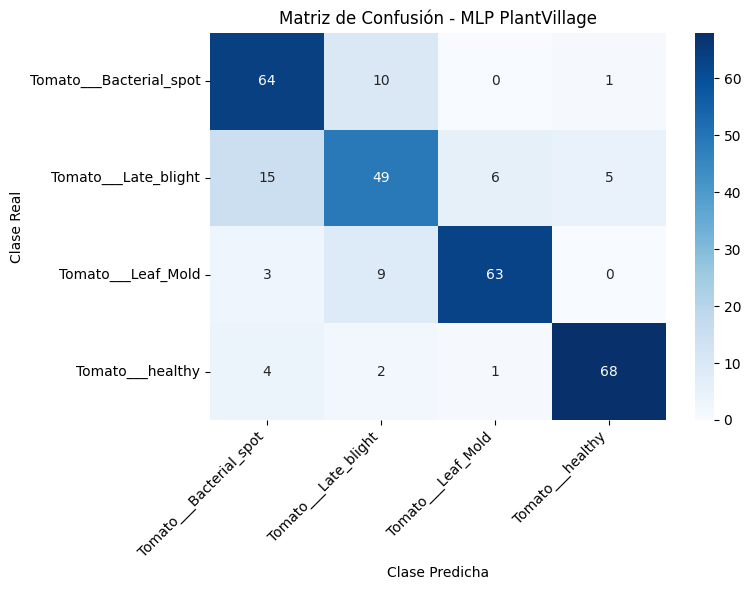


Total de imágenes mal clasificadas en Test: 56 de 300


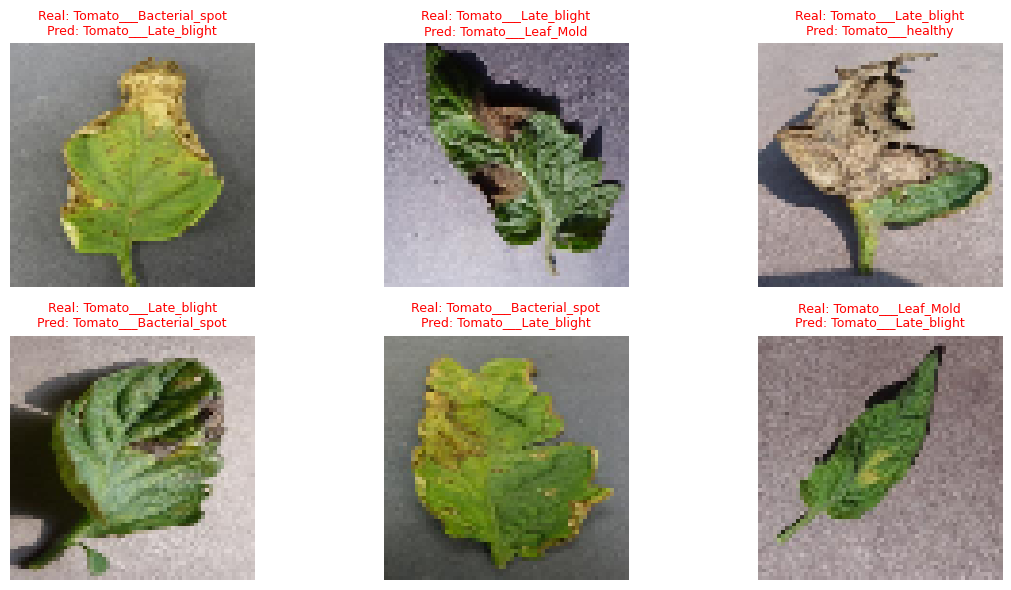


 Matriz de confusión guardada en: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/images/matriz_confusion.png
 Muestra de errores guardada en: /content/drive/MyDrive/proyecto_evaluacion_1_mlp/images/ejemplos_errores.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Obtener predicciones sobre el conjunto de prueba (Test)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Reporte de Métricas (Accuracy, Precision, Recall, F1-Score)
target_names = list(le.classes_)
print("=== REPORTE DE CLASIFICACIÓN (TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusión - MLP PlantVillage')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_path = os.path.join(proyecto_path, 'images', 'matriz_confusion.png')
plt.savefig(cm_path, bbox_inches='tight')
plt.show()

# 4. Inspección de Errores (Imágenes mal clasificadas)
indices_errores = np.where(y_pred != y_test)[0]
print(f"\nTotal de imágenes mal clasificadas en Test: {len(indices_errores)} de {len(y_test)}")

plt.figure(figsize=(12, 6))
num_muestras = min(6, len(indices_errores))

for idx, err_idx in enumerate(indices_errores[:num_muestras]):
    # Reconstruir imagen (64x64x3) a partir del vector aplanado
    img_flattened = X_test[err_idx]
    img_rgb = img_flattened.reshape(64, 64, 3)

    clase_real = target_names[y_test[err_idx]]
    clase_predicha = target_names[y_pred[err_idx]]

    plt.subplot(2, 3, idx + 1)
    plt.imshow(img_rgb)
    plt.title(f"Real: {clase_real}\nPred: {clase_predicha}", color='red', fontsize=9)
    plt.axis('off')

plt.tight_layout()
errores_path = os.path.join(proyecto_path, 'images', 'ejemplos_errores.png')
plt.savefig(errores_path, bbox_inches='tight')
plt.show()

print(f"\n Matriz de confusión guardada en: {cm_path}")
print(f" Muestra de errores guardada en: {errores_path}")